# Race Incidents - Safety Cars, Red Flags, and Fatal Accidents

Dataset from https://www.kaggle.com/datasets/jtrotman/formula-1-race-events
Please note that static images are displayed for GitHub repo. The code in this notebook creates interactive visualizations with plotly.

In [12]:
# load packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.graph_objects as go
from plotly import express as px
from IPython.display import Image, display
# from plotly.subplots import make_subplots

In [13]:
# load data
safety_cars = pd.read_csv("data/f1_race_events/safety_cars.csv")
red_flags = pd.read_csv("data/f1_race_events/red_flags.csv")
fatal_accidents_drivers = pd.read_csv("data/f1_race_events/fatal_accidents_drivers.csv")

# add year columns
safety_cars["Year"] = safety_cars["Race"].str[0:4].astype(int)
red_flags["Year"] = safety_cars["Race"].str[0:4].astype(int)

# convert date in fatal accidents dataframe
fatal_accidents_drivers["Date"] = pd.to_datetime(fatal_accidents_drivers["Date Of Accident"], format="%m/%d/%y")

# convert years in the future back to the 1900s
fatal_accidents_drivers.loc[fatal_accidents_drivers["Date"].dt.year > 2025, "Date"] -= pd.DateOffset(years=100)

# add year column to fatal accidents
fatal_accidents_drivers["Year"] = fatal_accidents_drivers["Date"].dt.year.astype(int)

## Safety Cars

In [14]:
# reasons for safety cars
safety_cars["Cause"].value_counts()

Cause
Accident                191
Stranded car             83
Rain                     27
Debris from accident     25
Debris from car           9
Two accidents             9
Multiple accidents        4
Man on track              3
Debris                    3
Stranded car/Rain         2
Loose drain cover         2
Two stranded cars         2
Accident/Rain             1
Four stranded cars        1
Three accidents           1
Accidents                 1
Vehicle on track          1
Name: count, dtype: int64

In [15]:
fatal_accidents_drivers.head()

,Driver,Age,Date Of Accident,Event,Car,Session,Date,Year
0,Cameron Earl,29.0,6/18/52,NaN,ERA,Test,1952-06-18,1952
1,Chet Miller,50.0,5/15/53,1953 Indianapolis 500,Kurtis Kraft,Practice,1953-05-15,1953
2,Charles de Tornaco,26.0,9/18/53,1953 Modena Grand Prix,Ferrari,Practice,1953-09-18,1953
3,Onofre Marimón,30.0,7/31/54,1954 German Grand Prix,Maserati,Practice,1954-07-31,1954
4,Mario Alborghetti,26.0,4/11/55,1955 Pau Grand Prix,Maserati,Race,1955-04-11,1955


/tmp/ipykernel_1701/3291360409.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fatal_summary = fatal_accidents_drivers.groupby('Year').apply(build_text).to_dict()


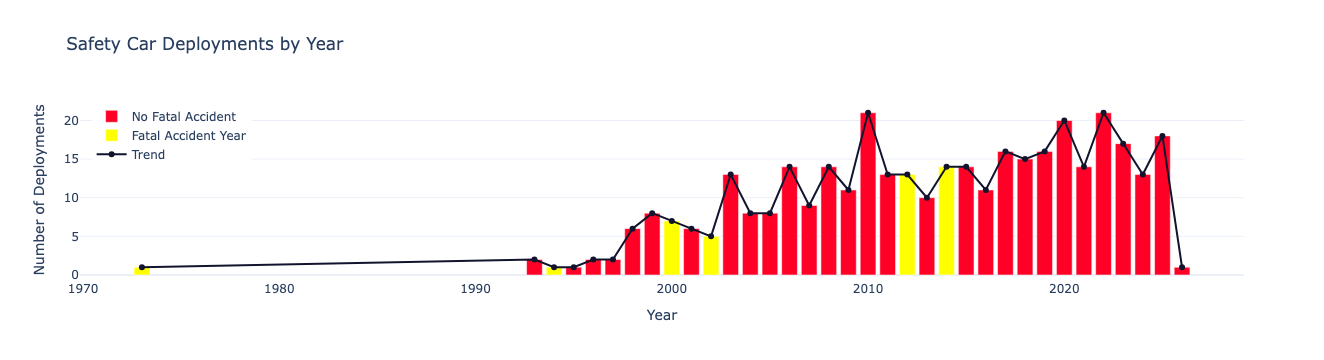

In [16]:
# safety car deployments by year

# prepare data

# safety car deployments per year
deployments_per_year = safety_cars['Year'].value_counts().sort_index()

years = deployments_per_year.index.tolist()
counts = deployments_per_year.values.tolist()

# build fatal accident hover info

def build_text(df):
    lines = []
    for _, row in df.iterrows():
        driver = str(row['Driver']) if pd.notna(row.get('Driver')) else "Unknown"
        event = str(row['Event']) if pd.notna(row.get('Event')) else ""
        
        if event:
            lines.append(f"{driver} – {event}")
        else:
            lines.append(driver)
    
    return "<br>".join(lines)

fatal_summary = fatal_accidents_drivers.groupby('Year').apply(build_text).to_dict()

fatal_years = list(fatal_summary.keys())

# split data based on fatal accidents

years_with_fatal = [y for y in years if y in fatal_years]
counts_with_fatal = [deployments_per_year[y] for y in years_with_fatal]

years_without_fatal = [y for y in years if y not in fatal_years]
counts_without_fatal = [deployments_per_year[y] for y in years_without_fatal]

# build hover text

hover_text_fatal = [
    f"Year: {y}<br>Deployments: {deployments_per_year[y]}<br><br>Fatal Accident(s): <br>{fatal_summary.get(y, '')}"
    for y in years_with_fatal
]

hover_text_nonfatal = [
    f"Year: {y}<br>Deployments: {deployments_per_year[y]}"
    for y in years_without_fatal
]

# create figure

fig = go.Figure()

# non-fatal years
fig.add_trace(go.Bar(
    x=years_without_fatal,
    y=counts_without_fatal,
    name='No Fatal Accident',
    marker_color="#FF0026",
    hovertext=hover_text_nonfatal,
    hoverinfo="text"
))

# fatal years
fig.add_trace(go.Bar(
    x=years_with_fatal,
    y=counts_with_fatal,
    name='Fatal Accident Year',
    marker_color="yellow",
    hovertext=hover_text_fatal,
    hoverinfo="text"
))

# trend line
fig.add_trace(go.Scatter(
    x=years,
    y=counts,
    name='Trend',
    mode='lines+markers',
    line=dict(color="#12142D", width=2)
))

# layout
fig.update_layout(
    title='Safety Car Deployments by Year',
    xaxis_title='Year',
    yaxis_title='Number of Deployments',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    barmode='group'
)

# fig.show()

# non-interactive images for github repo
display(Image("figures/safety_cars_year.png"))

# Note: halo introduced in 2018 after Jules Bianchi's fatal accident in 2014

In [17]:
# are there more safety car deployments at certain races?
safety_cars["Country"] = safety_cars["Race"].str[5:]

safety_cars["Country"].value_counts()

Country
Canadian Grand Prix          32
Australian Grand Prix        31
Monaco Grand Prix            25
British Grand Prix           23
Belgian Grand Prix           22
Singapore Grand Prix         22
Brazilian Grand Prix         21
Austrian Grand Prix          14
Japanese Grand Prix          14
Chinese Grand Prix           13
German Grand Prix            11
Italian Grand Prix           10
United States Grand Prix     10
Azerbaijan Grand Prix         9
Bahrain Grand Prix            9
Spanish Grand Prix            8
Hungarian Grand Prix          7
Korean Grand Prix             7
Russian Grand Prix            7
São Paulo Grand Prix          7
Dutch Grand Prix              6
Abu Dhabi Grand Prix          6
Malaysian Grand Prix          6
European Grand Prix           5
Qatar Grand Prix              5
Saudi Arabian Grand Prix      5
Emilia Romagna Grand Prix     4
Mexico City Grand Prix        3
French Grand Prix             3
Tuscan Grand Prix             3
Miami Grand Prix              2


## Fatal Accidents

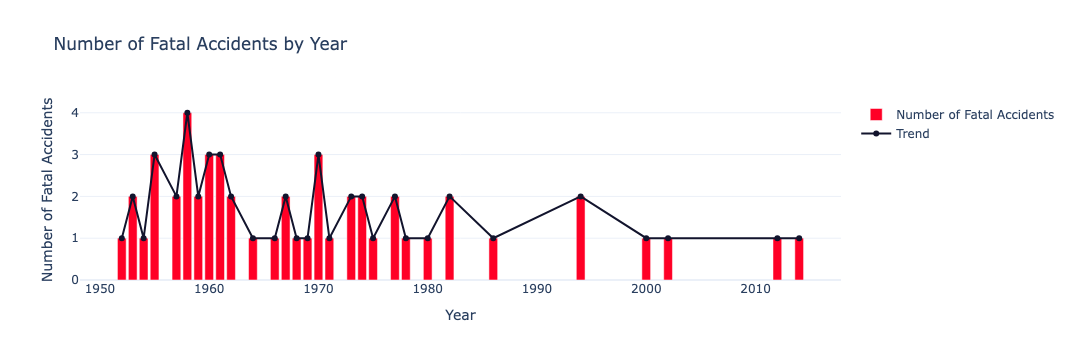

In [18]:
# fatal accidents per year
fatalities_per_year = fatal_accidents_drivers["Year"].value_counts().sort_index()

# prepare x and y values
years = fatalities_per_year.index.tolist()
counts = fatalities_per_year.values.tolist()

# create figure
fig = go.Figure()

# add bar trace
fig.add_trace(go.Bar(
    x=years,
    y=counts,
    name='Number of Fatal Accidents',
    marker_color="#FF0026"
))

# add line trace
fig.add_trace(go.Scatter(
    x=years,
    y=counts,
    name='Trend',
    mode='lines+markers',
    line=dict(color="#12142D", width=2)
))

# add titles and update layout
fig.update_layout(
    title='Number of Fatal Accidents by Year',
    xaxis_title='Year',
    yaxis_title='Number of Fatal Accidents',
    template='plotly_white'
)

# non-interactive images for github repo
display(Image("figures/fatal_accidents_year.png"))

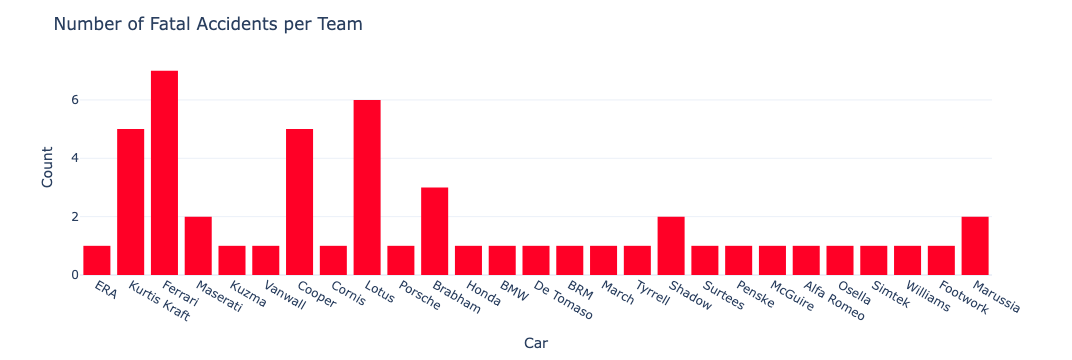

In [19]:
# fatal accidents for each team
fig = px.histogram(fatal_accidents_drivers,
                   x="Car",
)

fig.update_layout(
    yaxis_title="Count",
    title = "Number of Fatal Accidents per Team",
    template="plotly_white",
)

fig.update_traces(
    marker_color="#FF0026"
)

# fig.show()

# non-interactive images for github repo
display(Image("figures/fatal_accidents_team.png"))

In [20]:
# closer look at fatal accidents
print("Ferrari Fatal Accidents: \n")
display(fatal_accidents_drivers[fatal_accidents_drivers["Car"] == "Ferrari"])

print("\nLotus Fatal Accidents: \n")
display(fatal_accidents_drivers[fatal_accidents_drivers["Car"] == "Lotus"])

print("\nKurtis Kraft Fatal Accidents: \n")
display(fatal_accidents_drivers[fatal_accidents_drivers["Car"] == "Kurtis Kraft"])

Ferrari Fatal Accidents: 



,Driver,Age,Date Of Accident,Event,Car,Session,Date,Year
2,Charles de Tornaco,26.0,9/18/53,1953 Modena Grand Prix,Ferrari,Practice,1953-09-18,1953
7,Eugenio Castellotti,26.0,3/14/57,NaN,Ferrari,Test,1957-03-14,1957
10,Luigi Musso,33.0,7/6/58,1958 French Grand Prix,Ferrari,Race,1958-07-06,1958
11,Peter Collins,26.0,8/3/58,1958 German Grand Prix,Ferrari,Race,1958-08-03,1958
20,Wolfgang von Trips,33.0,9/10/61,1961 Italian Grand Prix,Ferrari,Race,1961-09-10,1961
25,Lorenzo Bandini,31.0,5/7/67,1967 Monaco Grand Prix,Ferrari,Race,1967-05-07,1967
42,Gilles Villeneuve,32.0,5/8/82,1982 Belgian Grand Prix,Ferrari,Qualifying,1982-05-08,1982



Lotus Fatal Accidents: 



,Driver,Age,Date Of Accident,Event,Car,Session,Date,Year
17,Alan Stacey,26.0,6/19/60,1960 Belgian Grand Prix,Lotus,Race,1960-06-19,1960
21,Ricardo Rodríguez,20.0,11/1/62,1962 Mexican Grand Prix,Lotus,Practice,1962-11-01,1962
22,Gary Hocking,25.0,12/21/62,1962 Natal Grand Prix,Lotus,Practice,1962-12-21,1962
31,Jochen Rindt,28.0,9/5/70,1970 Italian Grand Prix,Lotus,Qualifying,1970-09-05,1970
40,Ronnie Peterson,34.0,9/10/78,1978 Italian Grand Prix,Lotus,Race,1978-09-10,1978
47,John Dawson-Damer,59.0,6/24/00,2000 Goodwood Festival of Speed,Lotus,Demonstration,2000-06-24,2000



Kurtis Kraft Fatal Accidents: 



,Driver,Age,Date Of Accident,Event,Car,Session,Date,Year
1,Chet Miller,50.0,5/15/53,1953 Indianapolis 500,Kurtis Kraft,Practice,1953-05-15,1953
6,Bill Vukovich,36.0,5/30/55,1955 Indianapolis 500,Kurtis Kraft,Race,1955-05-30,1955
8,Keith Andrews,36.0,5/15/57,1957 Indianapolis 500,Kurtis Kraft,Practice,1957-05-15,1957
9,Pat O'Connor,29.0,5/30/58,1958 Indianapolis 500,Kurtis Kraft,Race,1958-05-30,1958
13,Jerry Unser Jr.,26.0,5/17/59,1959 Indianapolis 500,Kurtis Kraft,Pre-race test,1959-05-17,1959


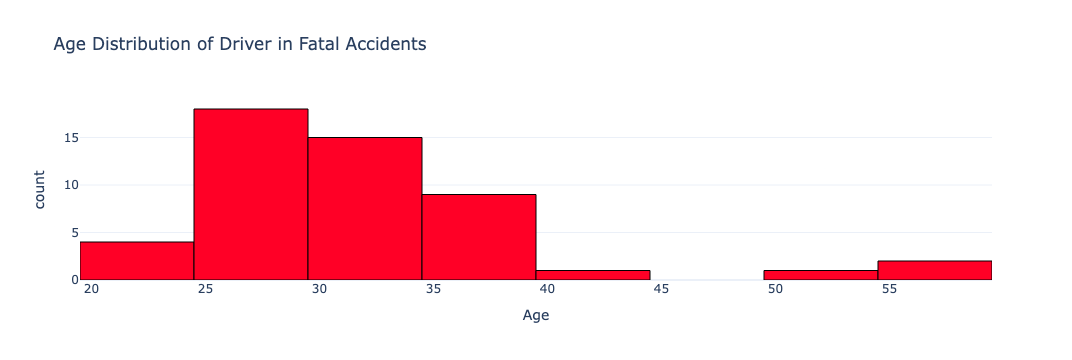

In [21]:
# ages of drivers in fatal accidents
fig = px.histogram(
    fatal_accidents_drivers,
    x='Age',
    nbins=10,  # adjust for granularity
    title="Age Distribution of Driver in Fatal Accidents",
    template="plotly_white"
)

fig.update_traces(marker_line_width=1, 
                  marker_line_color="black",
                 marker_color="#FF0026")

# fig.show()

# non-interactive images for github repo
display(Image("figures/fatal_accidents_age.png"))

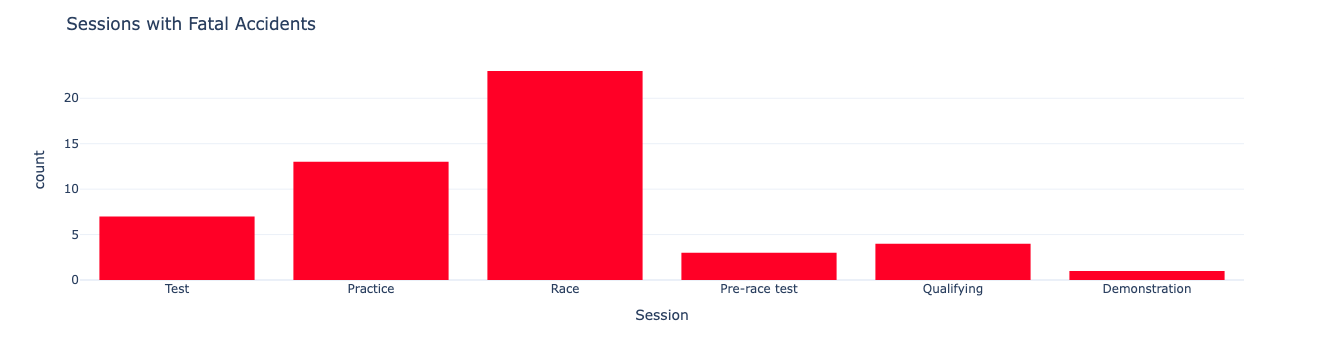

In [22]:
# type of session
fig = px.histogram(fatal_accidents_drivers,
                   x="Session",
)

fig.update_layout(
    template="plotly_white",
    title = "Sessions with Fatal Accidents"
)

fig.update_traces(
    marker_color="#FF0026"
)

# fig.show()

# non-interactive images for github repo
display(Image("figures/fatal_accidents_session.png"))

## Safety Cars and Fatal Accidents

In [23]:
# safety car deployments per year
deployments_per_year = safety_cars['Year'].value_counts()

# fatal accidents per year
fatal_accidents_per_year = fatal_accidents_drivers['Year'].value_counts()

# combine into one DataFrame, aligning years
combined_df = pd.concat(
    [deployments_per_year, fatal_accidents_per_year],
    axis=1
).fillna(0).astype(int).sort_index()

combined_df.columns = ['Safety Cars', 'Fatal Accidents']

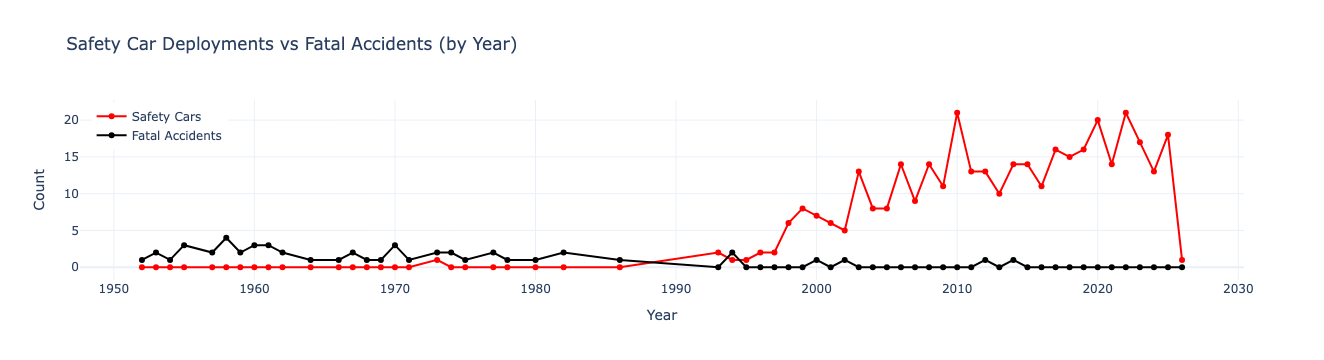

In [24]:
# safety car deployments and fatal accidents over time
fig = go.Figure()

# line for safety car deployments
fig.add_trace(go.Scatter(
    x=combined_df.index,
    y=combined_df['Safety Cars'],
    name='Safety Cars',
    mode='lines+markers',
    line=dict(color='red', width=2)
))

# line for fatal accidents
fig.add_trace(go.Scatter(
    x=combined_df.index,
    y=combined_df['Fatal Accidents'],
    name='Fatal Accidents',
    mode='lines+markers',
    line=dict(color='black', width=2)
))

# layout customization
fig.update_layout(
    title='Safety Car Deployments vs Fatal Accidents (by Year)',
    xaxis_title='Year',
    yaxis_title='Count',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    hovermode='x unified'
)

# fig.show()

# non-interactive images for github repo
display(Image("figures/fatal_accidents_safety_cars.png"))